# 相对位置编码，早期的，可以跳过

In [ ]:
import torch  # 导入PyTorch库
import torch.nn as nn  # 导入PyTorch神经网络模块
import math  # 导入数学库，包含开方等操作
from torch.nn import functional as F  # 导入PyTorch的函数式(Functional)API模块

# =====================================
# 相对位置编码(RelativePositionEmbedding)模块
# 注意：该相对位置编码是有可学习参数的
# =====================================
class RelativePositionEmbedding(nn.Module):
    def __init__(self, max_seq_len: int, embedding_dim: int):
        """
        参数:
            max_seq_len: 支持的最大序列长度，用于预留最大相对位置范围
            embedding_dim: 每个相对位置的嵌入向量维度
        """
        super().__init__()
        self.max_seq_len = max_seq_len  # 记录最大支持的序列长度
        self.embedding_dim = embedding_dim  # 嵌入维度
        # 构造可学习参数，shape: [max_seq_len*2-1, embedding_dim]
        # 用于存储 "从- (max_seq_len-1) ~ (max_seq_len-1)" 的每一个相对位移的嵌入
        self.relative_positions = nn.Parameter(
            torch.randn(max_seq_len * 2 - 1, embedding_dim)
        )  # 参数初始化为标准正态分布

    def forward(self, seq_len: int):
        """
        给定当前输入序列长度，返回相对位置嵌入矩阵，形状为 [seq_len, seq_len, embedding_dim]
        每个 [i,j] 位置 代表第i个token对第j个token的相对位置的嵌入
        """
        # 生成相对位置索引矩阵, shape: (seq_len, seq_len)
        relative_positions_matrix = self._generate_relative_positions_matrix(seq_len)
        # 通过F.embedding查表拿到每对(i,j)的嵌入向量
        # 输出形状: (seq_len, seq_len, embedding_dim)
        relative_embeddings = F.embedding(relative_positions_matrix, self.relative_positions)
        return relative_embeddings

    def _generate_relative_positions_matrix(self, seq_len: int):
        """
        构造一个(seq_len, seq_len)的相对位置索引矩阵。
        其中每个元素(i, j)为 (i-j) + max_seq_len - 1
        即用一个大的偏移量shift使所有值都为正，可以作为embedding的索引。
        
        例如 max_seq_len=5, 则从-4~+4，经过shift变成0~8。
        """
        range_vec = torch.arange(seq_len)  # [0, 1, ..., seq_len-1]
        # 构造行、列分别为顺序号的两个矩阵
        range_matrix = range_vec.unsqueeze(0).expand(seq_len, seq_len)  # 每一行相同
        # 取差, 行-列 得到[i-j]，shape: (seq_len, seq_len)
        distance_matrix = range_matrix - range_matrix.t()
        # 加上offset，把负的变正，使其适合作为embedding查表索引
        distance_matrix = distance_matrix + self.max_seq_len - 1
        return distance_matrix  # 返回相对位置索引矩阵

# =====================================
# 多头自注意力(MultiHeadAttention)模块，集成了带相对位置编码的注意力计算
# =====================================
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, max_seq_len: int):
        """
        参数:
            embed_dim: 输入向量的全部维度大小 (会被均分到各个头)
            num_heads: 多头数量
            max_seq_len: 用于支持的最大输入序列长度(传递给相对位置编码)
        """
        super().__init__()
        self.embed_dim = embed_dim  # 原始空间的维度
        self.num_heads = num_heads  # 头数
        self.head_dim = embed_dim // num_heads  # 每个头工作在head_dim维度空间
        # Q/K/V分别为一层线性映射
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        # 注意: 每个头用一套相对位置编码(见论文AAN/mT5等主流写法)
        self.rel_pos_embeddings = RelativePositionEmbedding(max_seq_len, self.head_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, query: torch.Tensor, key: torch.Tensor, value: torch.Tensor):
        """
        输入:
            query, key, value: shape = (batch_size, seq_len, embed_dim)
        返回:
            output: shape = (batch_size, seq_len, embed_dim)
        """
        batch_size, seq_len, embed_dim = query.size()  # 获取三者的形状
        # Linear projection and reshape for multi-head
        # [B, T, C] -> [B, T, num_heads, head_dim] -> [B, num_heads, T, head_dim]
        query = self.q_proj(query).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        key = self.k_proj(key).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        value = self.v_proj(value).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        # 形状都变成 (batch_size, num_heads, seq_len, head_dim)

        # 标准注意力分数 QK^T，结果 [B, num_heads, T, T]
        attention_scores = torch.matmul(query, key.transpose(-1, -2))
        
        # 获取相对位置嵌入 [seq_len, seq_len, head_dim]
        rel_pos_embeddings = self.rel_pos_embeddings(seq_len)
        # 计算相对位置注意力分数
        # query: [B, num_heads, seq_len, head_dim], rel_pos_embeddings: [seq_len, seq_len, head_dim]
        # einsum方式: l为query的token pos, r为key的token pos, d为head_dim
        # 输出: (B, num_heads, seq_len, seq_len), 表示q_i与k_j每对引入的相对位置信息
        rel_attention_scores = torch.einsum('bhld,lrd->bhlr', query, rel_pos_embeddings)
        # 注意einsum详细说明：
        # bhld: b=批次，h=头数，l=token pos，d=头特征
        # lrd:  l=token pos，r=token pos，d=头特征
        # bhlr: b=批次，h=头数，l=查询位置，r=键位置

        # 合并绝对与相对位置信息
        attention_scores += rel_attention_scores

        # 进行缩放操作（防止梯度爆炸），除以sqrt(head_dim)
        attention_scores = attention_scores / math.sqrt(self.head_dim)

        # 在最后一个维度（即所有key）上softmax归一化，得到每个query的attention分布
        attention_weights = F.softmax(attention_scores, dim=-1)

        # 加权求和得到输出，(batch_size, num_heads, seq_len, head_dim)
        output = torch.matmul(attention_weights, value)
        # 变回[batch_size, seq_len, embed_dim]
        # 先permute回去再flatten
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)
        # 输出层映射
        output = self.out_proj(output)
        return output

# ==========================
# 使用示例
# ==========================

max_seq_len = 10    # 支持最大长度
embed_dim = 64      # 输入向量总维度
num_heads = 4       # 注意力头数
batch_size = 2      # 批大小
seq_len = 5         # 实际输入序列长度

# 随机造数据
query = torch.randn(batch_size, seq_len, embed_dim)
key   = torch.randn(batch_size, seq_len, embed_dim)
value = torch.randn(batch_size, seq_len, embed_dim)

# 实例化注意力模块
attention = MultiHeadAttention(embed_dim, num_heads, max_seq_len)

# 测试各核心组件 ==========================
print("相对位置矩阵:")
# _generate_relative_positions_matrix(5)：输出5x5的相对位置偏移值矩阵
print(attention.rel_pos_embeddings._generate_relative_positions_matrix(5))

# 查看可学习相对位置编码表的参数形状
print(f"相对位置嵌入参数形状: {attention.rel_pos_embeddings.relative_positions.shape}")

# 给定序列长度5，得到每一对token的相对位置嵌入，形状[5,5,head_dim]
print(f"序列长度为5的相对位置嵌入形状: {attention.rel_pos_embeddings(5).shape}")

# 测试前向：输出shape应为 (batch_size, seq_len, embed_dim)
output = attention(query, key, value)
print(f"输出形状: {output.shape}")

相对位置矩阵:
tensor([[ 9, 10, 11, 12, 13],
        [ 8,  9, 10, 11, 12],
        [ 7,  8,  9, 10, 11],
        [ 6,  7,  8,  9, 10],
        [ 5,  6,  7,  8,  9]])
相对位置嵌入参数形状: torch.Size([19, 16])
序列长度为5的相对位置嵌入形状: torch.Size([5, 5, 16])
输出形状: torch.Size([2, 5, 64])


# 旋转位置编码

测试旋转位置编码(RoPE)
输入形状: torch.Size([2, 10, 128])
输出形状: torch.Size([2, 10, 128])
注意力权重形状: torch.Size([2, 8, 10, 10])

测试相对位置特性:
序列1注意力权重形状: torch.Size([1, 8, 5, 5])
序列2注意力权重形状: torch.Size([1, 8, 7, 7])
RoPE有助于保持序列中元素的相对位置关系

比较RoPE与绝对位置编码:
RoPE优势:
1. 更好的相对位置建模
2. 对序列长度的泛化能力更强
3. 在长序列上性能更稳定

绝对位置编码特点:
1. 直接添加到输入embeddings
2. 简单但可能丢失相对位置信息
3. 对序列长度敏感


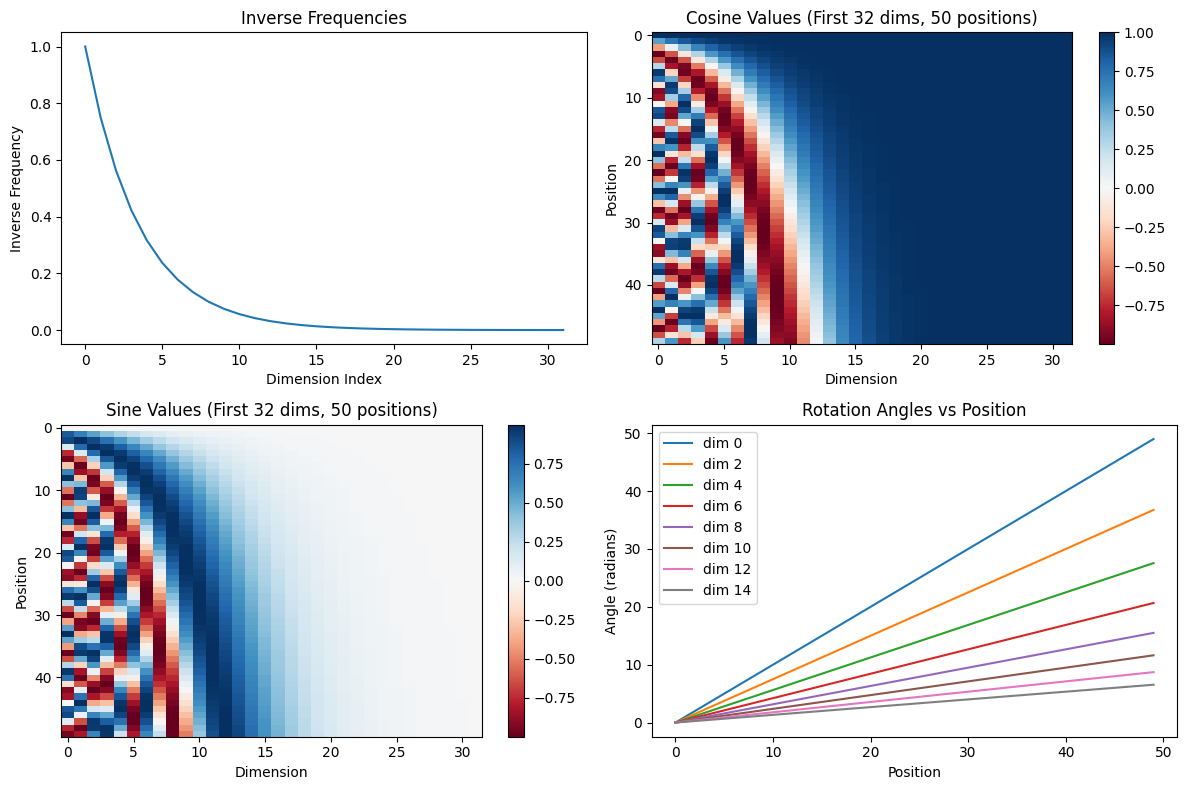


旋转位置编码(RoPE)示例完成！


In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import numpy as np

class RotaryPositionalEmbedding(nn.Module):
    """
    旋转位置编码 (RoPE - Rotary Position Embedding)
    
    RoPE的核心思想：用旋转矩阵（即正余弦对）来编码位置信息，能让自注意力更直接地利用token间的相对位置关系。
    这样不仅具备绝对位置信息，而且可以直接让注意力模式感知到序列token间的相对位移。
    """

    def __init__(self, dim, max_position_embeddings=2048, base=10000):
        """
        Args:
            dim: 每个注意力head的特征维度
            max_position_embeddings: 支持的最大序列长度，用于提前缓存sin/cos表
            base: 频率分母基数，默认和Transformer/WordEmbedding一致（常为10000）
        """
        super().__init__()
        self.dim = dim  # 特征维度（通常为head_dim）
        self.max_position_embeddings = max_position_embeddings  # 支持的最大长度
        self.base = base  # 频率的底数

        # 计算每个偶数维度的逆频率系数（公式：1/base^(2i/dim)）
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        # 将inv_freq注册到buffer里（不会被优化、可自动迁移设备）
        self.register_buffer('inv_freq', inv_freq)

        # 缓存cos和sin表，避免多次重复计算
        self._set_cos_sin_cache(max_position_embeddings)

    def _set_cos_sin_cache(self, seq_len):
        """
        为指定的序列长度预计算cos/sin值的表格，用于快速查表
        Args:
            seq_len: 预设表格大小（通常设为最大支持序列长度）
        """
        # 位置索引 [0,1,2,...,seq_len-1]
        t = torch.arange(seq_len, dtype=self.inv_freq.dtype, device=self.inv_freq.device)
        # 外积得到每个位置 × 每个频率
        # 得到shape: [seq_len, dim//2]
        freqs = torch.outer(t, self.inv_freq)
        # RoPE要在偶/奇两个特征上分别混合，所以拼接一份，让最终dim和head_dim对应
        emb = torch.cat((freqs, freqs), dim=-1)  # [seq_len, dim]
        # 预先算好所有位置-各频率（维度）的cos、sin表
        self.register_buffer('cos_cached', emb.cos())  # shape: [seq_len, dim]
        self.register_buffer('sin_cached', emb.sin())  # shape: [seq_len, dim]

    def forward(self, x, seq_len=None):
        """
        对输入张量应用旋转位置编码（RoPE），即用正余弦对偶数维度特征进行编码
        Args:
            x: 输入张量，shape为 [batch_size, seq_len, num_heads, head_dim]
            seq_len: 实际序列长度，默认为x的第二维
        Returns:
            应用RoPE后的张量，shape同x
        """
        if seq_len is None:
            seq_len = x.shape[1]

        # 若实际序列长度超出缓存则扩容缓存
        if seq_len > self.cos_cached.shape[0]:
            self._set_cos_sin_cache(seq_len)

        # 截取前seq_len长度的cos和sin，用于编码
        cos = self.cos_cached[:seq_len]
        sin = self.sin_cached[:seq_len]

        # 应用旋转位置编码
        return self.apply_rotary_pos_emb(x, cos, sin)

    def apply_rotary_pos_emb(self, x, cos, sin):
        """
        真正进行旋转（复数运算形式的二维切片混合）
        Args:
            x: 输入，shape [batch_size, seq_len, num_heads, head_dim]
            cos, sin: 对应位置和频率的cos,sin，shape [seq_len, head_dim]
        Returns:
            旋转后的特征
        """
        # 补充批次&头，扩展到[1, seq_len, 1, head_dim]方便广播到x
        cos = cos.unsqueeze(0).unsqueeze(2)  # shape: [1, seq_len, 1, head_dim]
        sin = sin.unsqueeze(0).unsqueeze(2)  # shape: [1, seq_len, 1, head_dim]

        # 把head_dim两两分组（偶/奇号），分别拿出来做二维旋转
        x1 = x[..., ::2]  # 偶数维（实部，或第1个分量）
        x2 = x[..., 1::2] # 奇数维（虚部，或第2个分量）

        # cos/sin也只保留对应一半的维度（head_dim/2），与x1/x2对齐
        cos_half = cos[..., ::2]
        sin_half = sin[..., ::2]

        # 复数乘法对应的二维旋转（详见roformer、llama等实现/论文公式4）
        # [x1*cos - x2*sin, x1*sin + x2*cos]
        rotated_x1 = x1 * cos_half - x2 * sin_half  # 新的偶数维
        rotated_x2 = x1 * sin_half + x2 * cos_half  # 新的奇数维

        # 还原到原始交错排列（偶-奇-偶-奇...）
        rotated_x = torch.zeros_like(x)
        rotated_x[..., ::2] = rotated_x1
        rotated_x[..., 1::2] = rotated_x2

        return rotated_x

class MultiHeadAttentionWithRoPE(nn.Module):
    """
    多头注意力机制的示例实现，集成RoPE编码
    """
    def __init__(self, d_model, num_heads, max_position_embeddings=2048):
        """
        Args:
            d_model: 总特征维度（会均分到每个注意力头）
            num_heads: 注意力头数
            max_position_embeddings: RoPE支持的最大长度
        """
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads  # 每个头的特征维度

        assert self.head_dim * num_heads == d_model, "d_model 必须能被 num_heads 整除"

        # QKV的线性变换（和标准Transformer一致）
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.o_proj = nn.Linear(d_model, d_model)

        # RoPE实例，每个head_dim都有自己的编码表
        self.rotary_emb = RotaryPositionalEmbedding(self.head_dim, max_position_embeddings)

        # 注意力缩放因子（防止softmax爆炸）
        self.scale = self.head_dim ** -0.5

    def forward(self, x, mask=None):
        """
        Args:
            x: 输入特征，shape [batch_size, seq_len, d_model]
            mask: 掩码
        Returns:
            output: 编码与注意力融合后的结果，shape [batch_size, seq_len, d_model]
            attn_weights: 注意力权重，shape [batch_size, num_heads, seq_len, seq_len]
        """
        batch_size, seq_len, _ = x.shape

        # 线性投影到Q,K,V（与标准多头注意力一致）
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)
        # 重塑为多头格式 [batch, seq_len, num_heads, head_dim]
        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_dim)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_dim)

        # 对query/key应用旋转位置编码（RoPE）
        q = self.rotary_emb(q, seq_len)
        k = self.rotary_emb(k, seq_len)

        # 变换到 [batch, num_heads, seq_len, head_dim]
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # 注意力分数 b,h,i,j = q·k^T （内积+缩放）
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale

        # 如果有mask则应用，通常mask==0的位置置为负无穷
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # softmax归一化 得到注意力分布
        attn_weights = torch.softmax(scores, dim=-1)

        # 用注意力分布加权value
        attn_output = torch.matmul(attn_weights, v)  # [batch, num_heads, seq_len, head_dim]

        # 合并多头 [batch, seq_len, d_model]
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        # 输出投影再输出
        output = self.o_proj(attn_output)

        return output, attn_weights

def visualize_rope():
    """
    可视化RoPE编码内部的频率分布与角度变化
    展示正余弦表、多频率和对应角度随位置的变化
    """
    dim = 64
    max_len = 100
    # 创建RoPE对象
    rope = RotaryPositionalEmbedding(dim, max_len)
    # 创建一个随机输入张量 [1, max_len, 1, dim]
    x = torch.randn(1, max_len, 1, dim)
    # 仅为了激活forward，实际不会用输出
    rotated_x = rope(x)

    plt.figure(figsize=(12, 8))

    # 子图1： 频率分布（不同维度的“逆频率”参数值）
    plt.subplot(2, 2, 1)
    plt.plot(rope.inv_freq.numpy())
    plt.title('Inverse Frequencies')
    plt.xlabel('Dimension Index')
    plt.ylabel('Inverse Frequency')

    # 子图2： cos表 可视化（前50个位置×前32个维度）
    plt.subplot(2, 2, 2)
    cos_matrix = rope.cos_cached[:50, :32].numpy()
    plt.imshow(cos_matrix, cmap='RdBu', aspect='auto')
    plt.title('Cosine Values (First 32 dims, 50 positions)')
    plt.xlabel('Dimension')
    plt.ylabel('Position')
    plt.colorbar()

    # 子图3： sin表 可视化（前50个位置×前32个维度）
    plt.subplot(2, 2, 3)
    sin_matrix = rope.sin_cached[:50, :32].numpy()
    plt.imshow(sin_matrix, cmap='RdBu', aspect='auto')
    plt.title('Sine Values (First 32 dims, 50 positions)')
    plt.xlabel('Dimension')
    plt.ylabel('Position')
    plt.colorbar()

    # 子图4： 角度随位置变化（只取前8种频率）
    plt.subplot(2, 2, 4)
    positions = torch.arange(50)
    angles = torch.einsum('i,j->ij', positions.float(), rope.inv_freq[:8])
    for i in range(8):
        plt.plot(positions, angles[:, i], label=f'dim {i*2}')
    plt.title('Rotation Angles vs Position')
    plt.xlabel('Position')
    plt.ylabel('Angle (radians)')
    plt.legend()
    plt.tight_layout()
    plt.show()

def test_rope_example():
    """
    测试RoPE主要功能，包括shape匹配和基本序列相对关系的保持
    """
    print("测试旋转位置编码(RoPE)")
    # 构造样例参数
    batch_size = 2
    seq_len = 10
    d_model = 128
    num_heads = 8

    # 新建带RoPE的多头注意力模块
    attention = MultiHeadAttentionWithRoPE(d_model, num_heads)
    # 随机输入
    x = torch.randn(batch_size, seq_len, d_model)
    # 前向推理
    output, attn_weights = attention(x)
    print(f"输入形状: {x.shape}")
    print(f"输出形状: {output.shape}")
    print(f"注意力权重形状: {attn_weights.shape}")

    print("\n测试相对位置特性:")

    # 补充测试：构造两个类似（但有位移）的输入，比较注意力
    seq1 = torch.randn(1, 5, d_model)
    seq2 = torch.cat([torch.zeros(1, 2, d_model), seq1], dim=1)  # seq2较seq1右移2位
    _, attn1 = attention(seq1)
    _, attn2 = attention(seq2)
    print(f"序列1注意力权重形状: {attn1.shape}")
    print(f"序列2注意力权重形状: {attn2.shape}")
    print("RoPE有助于保持序列中元素的相对位置关系")

def compare_with_absolute_pe():
    """
    对比RoPE与标准绝对位置编码（如Transformer论文实现）
    """
    print("\n比较RoPE与绝对位置编码:")
    d_model = 64
    seq_len = 20

    # 创建RoPE编码
    rope = RotaryPositionalEmbedding(d_model, seq_len)

    # 绝对位置编码公式（和Transformer/Pytorch官方一致）
    position = torch.arange(seq_len).unsqueeze(1)  # [seq_len, 1]
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))  # [d_model/2]
    abs_pe = torch.zeros(seq_len, d_model)
    abs_pe[:, 0::2] = torch.sin(position * div_term)
    abs_pe[:, 1::2] = torch.cos(position * div_term)

    print("RoPE优势:")
    print("1. 更好的相对位置建模")
    print("2. 对序列长度的泛化能力更强")
    print("3. 在长序列上性能更稳定")
    print("\n绝对位置编码特点:")
    print("1. 直接添加到输入embeddings")
    print("2. 简单但可能丢失相对位置信息")
    print("3. 对序列长度敏感")

if __name__ == "__main__":
    # 运行RoPE功能测试（主要是shape匹配与相对位置能力）
    test_rope_example()
    # 对比RoPE与绝对sin/cos位置编码
    compare_with_absolute_pe()
    # 画可视化图示，直观看到sin/cos表的规律
    try:
        visualize_rope()
    except ImportError:
        print("需要安装matplotlib来运行可视化: pip install matplotlib")
    print("\n旋转位置编码(RoPE)示例完成！")

 右上图：Cosine Values (First 32 dims, 50 positions)
标题：Cosine Values（前 32 个维度，前 50 个位置）

横轴：维度（Dimension）

纵轴：位置（Position）

色彩：cos 值的大小（-1 ~ 1）

✅ 含义：
展示了每个位置和维度对应的 cos(θ) 值分布。

可以看到：

越靠左（低维），周期越短（频率高）

越靠右（高维），cos 变化更缓慢（频率低）

说明：RoPE 对不同维度使用不同频率的正余弦编码，以组合出丰富的位置特征

🔶 左下图：Sine Values (First 32 dims, 50 positions)
标题：Sine Values（前 32 个维度，前 50 个位置）

格式和右上图一样，只不过是展示的 sin 值。

✅ 含义：
与 cos 一样，sin 值也是周期性的，频率递减。

这些 sin 和 cos 会被用于对 query/key 的不同维度进行“复数式旋转”（即二维旋转）。